In [263]:
import pandas as pd
import sqlite3
import datetime
from os import path
import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

#--------Directories ---------------------------------------
## Project directory
project_dir = path.dirname(path.dirname(path.abspath('')))

## Location of database files
db_dir = path.join(project_dir,"files", "data", "lfs", "UWB")

## Location for Graphs
graph_dir = path.join(project_dir, "files", "data", "lfs","UWB",  "graphs")

In [265]:
def filter_db_files(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db"
    ) -> list:
    if station_id == None:
        station_id ="*"

    if component == None:
        component = "*"

    if scope == None:
        scope = "*"

    mask = f'station_{station_id}*_comp_{component}*_scope_{scope}*{file_type}'
    files = glob.glob(path.join(db_dir, mask))
    files_filterd = []
    for file in files:
        if path.getsize(file) >= min_filesize:
            files_filterd.append(file)
    return files_filterd

In [ ]:
def generate_lineplot(df, select_date_start= None, select_date_end = None, component = None, scope = None, save_fig=True, graphs_dir = graph_dir):

    # Use the full timedelta of the df if no dates are specificed
    if select_date_start == None:
        start = str(df['date_start'].iloc[0])
    else:
        start = select_date_start
    if select_date_end == None:
        end= str(df['date_start'].iloc[-1])
    else:
        end = select_date_end

    df_plt = df.query(f'date_start >= "{start}" and date_start < "{end}"')
    
    ## Generate the figure
    plt.figure(figsize=(40,10))
    sns.lineplot(df_plt ,x="date_start", y="value", hue="station_id")
    plt.title("Please give title")
   
    ### Save figure as pdf
    if save_fig:
        plt_name = f'UWB_{select_date_start}--{select_date_end}.pdf'
        file_path = path.join(graph_dir, plt_name)
        plt.savefig(file_path)
    plt.show()

In [285]:
def load_dbs(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db",
        project_dir: str = 'files/data/lfs/UWB'
    ) -> list:
    dfs = []
    files = filter_db_files(station_id, component, scope, min_filesize, file_type)
    for file in files:
        conn = sqlite3.connect(file)
        df = pd.read_sql_query("SELECT * FROM measurements", conn)
        dfs.append(df)
    df = pd.concat(dfs,ignore_index=True)

    # 1. Identify which rows have the 24:00:00 problem
    mask = df["date_end"].str.contains("24:00:00")

    # 2. Replace 24:00:00 with 00:00:00 so pandas can parse it
    df["date_end"] = df["date_end"].str.replace("24:00:00", "00:00:00")

    # 3. Convert to datetime
    df["date_end"] = pd.to_datetime(df["date_end"])

    # 4. Add exactly 1 day to the rows that originally had 24:00:00
    df.loc[mask, "date_end"] += pd.Timedelta(days=1)
    df["date_start"] = pd.to_datetime(df["date_start"])
    df["date_end"] = pd.to_datetime(df["date_end"])
    df["station_id"] = df["station_id"].astype(str)
    df = df.drop("index_value", axis=1)

    return df

In [286]:
df = load_dbs("*", component=1, scope=2, project_dir=db_dir)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 596112 entries, 0 to 596111
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_start    596112 non-null  datetime64[us]
 1   date_end      596112 non-null  datetime64[us]
 2   station_id    596112 non-null  str           
 3   component_id  596112 non-null  int64         
 4   scope_id      596112 non-null  int64         
 5   value         581529 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(2), str(1)
memory usage: 27.3 MB


In [280]:
df['date_start'].iloc[0]

Timestamp('2024-01-01 00:00:00')

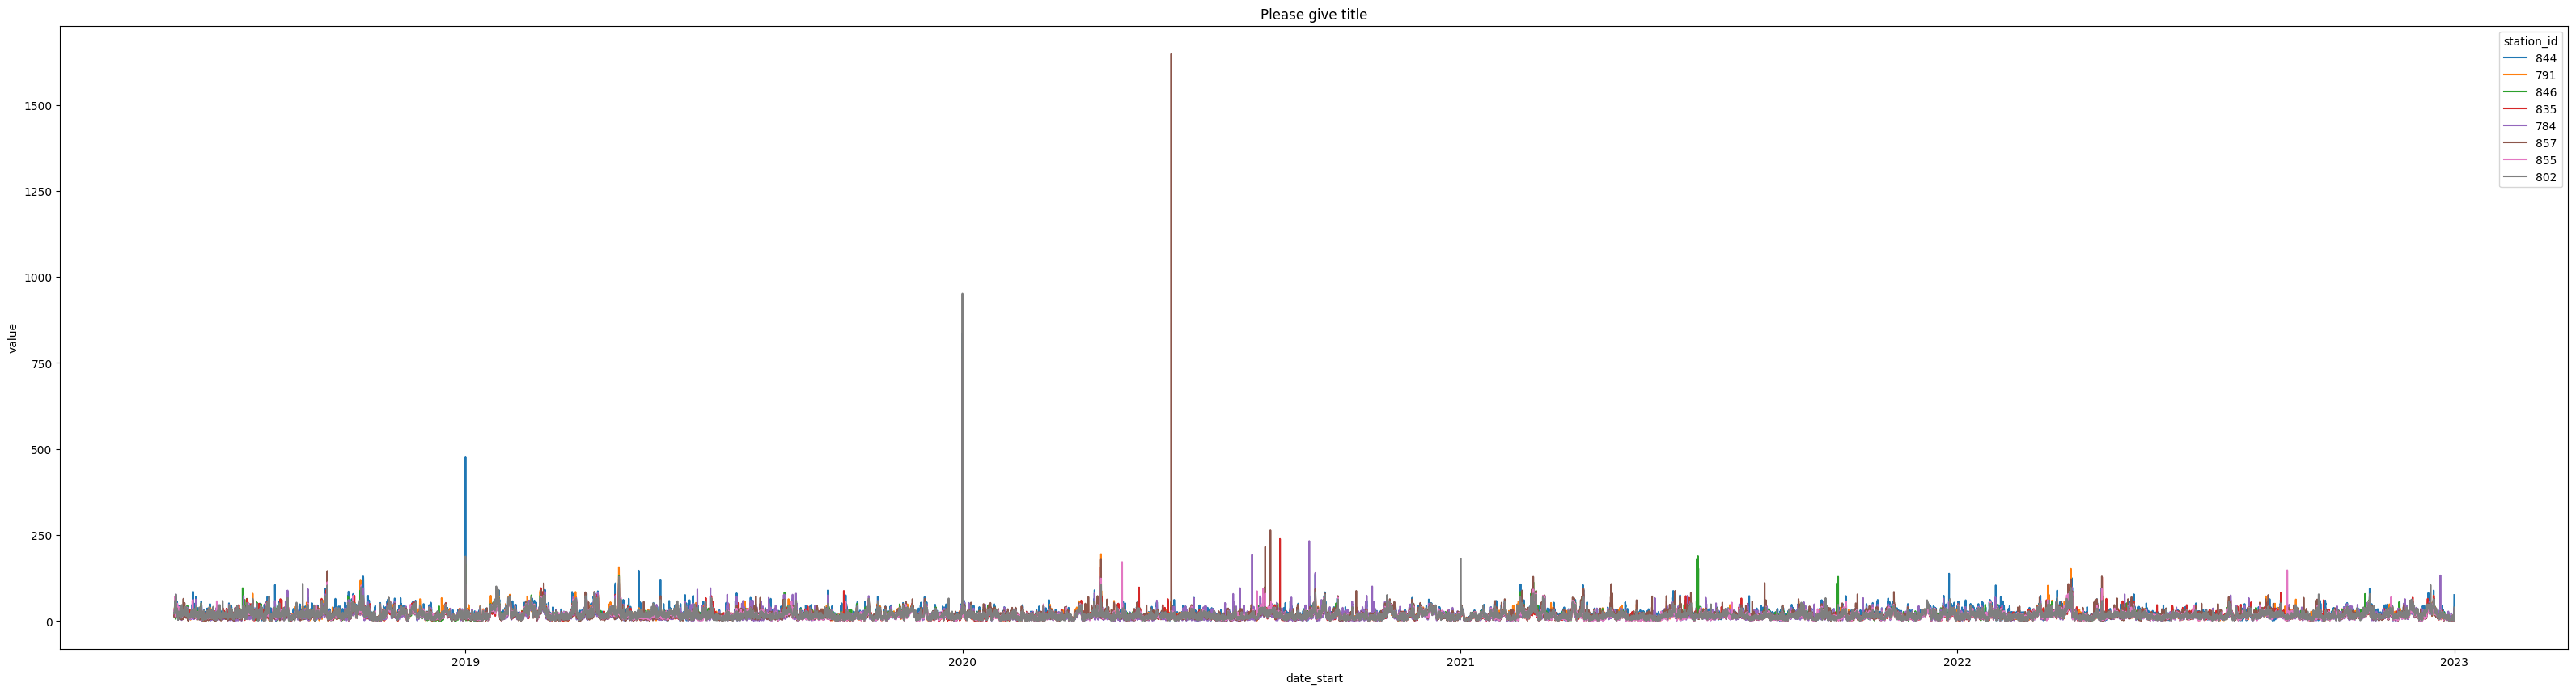

In [302]:
## format for dates: '2024-01-01 00:00:00' or shorter e.g. 2022-02 or 2018
generate_lineplot(df,select_date_start='2018-06',select_date_end= '2023')